#Notebook Overview
This Test file attempts to implment a different model architecture to improve models accuracy. This implemntation uses momentum as its optimizer

# Conclusion

Model achieves 60% accuracy om test data and 66% on validation data

In [1]:
try:
  # This command only in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import os
import numpy as np
import matplotlib.pyplot as plt

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [2]:
# Get project files from internet
!wget https://cdn.freecodecamp.org/project-data/cats-and-dogs/cats_and_dogs.zip

!unzip cats_and_dogs.zip #extracts file

PATH = 'cats_and_dogs'

train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')
test_dir = os.path.join(PATH, 'test')

# Get number of files in each directory. The train and validation directories
# each have the subdirecories "dogs" and "cats".
#counts no of files in each drectory
total_train = sum([len(files) for r, d, files in os.walk(train_dir)])
total_val = sum([len(files) for r, d, files in os.walk(validation_dir)])
total_test = len(os.listdir(test_dir))

# Variables for pre-processing and training.
batch_size = 128
epochs = 15
IMG_HEIGHT = 150
IMG_WIDTH = 150

Streaming output truncated to the last 5000 lines.
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.60.jpg  
  inflating: cats_and_dogs/train/dogs/dog.858.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.858.jpg  
  inflating: cats_and_dogs/train/dogs/dog.680.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.680.jpg  
  inflating: cats_and_dogs/train/dogs/dog.694.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.694.jpg  
  inflating: cats_and_dogs/train/dogs/dog.864.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.864.jpg  
  inflating: cats_and_dogs/train/dogs/dog.870.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.870.jpg  
  inflating: cats_and_dogs/train/dogs/dog.871.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.871.jpg  
  inflating: cats_and_dogs/train/dogs/dog.865.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.865.jpg  
  inflating: cats_and_dogs/train/dogs/dog.695.jpg  
  inflating: __MACOSX/cats_and

In [3]:
print(total_train,total_test,total_val)

2001 51 1001


In [4]:
# 3
train_image_generator = ImageDataGenerator(rescale = 1./ 255) #ensures float division is applied
validation_image_generator =  ImageDataGenerator(rescale = 1./ 255)

#Applying transformations
test_image_generator =  ImageDataGenerator(rescale = 1./ 255)

train_data_gen = train_image_generator.flow_from_directory(train_dir,batch_size = batch_size,target_size = (IMG_HEIGHT,IMG_WIDTH), class_mode = 'binary')
val_data_gen = validation_image_generator.flow_from_directory(validation_dir,batch_size = batch_size,target_size = (IMG_HEIGHT,IMG_WIDTH), class_mode = 'binary')


Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [5]:
test_data_gen = test_image_generator.flow_from_directory(test_dir,target_size = (IMG_HEIGHT,IMG_WIDTH))

Found 0 images belonging to 0 classes.


In [6]:
'''
flow from directory expects nested directories sincetest folder lacks one the appropriate decision is t point back to the parent then direct it to test
'''
parent_dir = PATH

test_data_gen = test_image_generator.flow_from_directory(parent_dir,classes = ['test'],target_size = (IMG_HEIGHT,IMG_WIDTH),batch_size = batch_size,shuffle = False,class_mode=None)


Found 50 images belonging to 1 classes.


In [7]:
#visulizing test data
test_images = os.listdir(test_dir)
file_names = [os.path.join(test_dir,f) for f in test_images]
print(file_names)

['cats_and_dogs/test/43.jpg', 'cats_and_dogs/test/20.jpg', 'cats_and_dogs/test/28.jpg', 'cats_and_dogs/test/8.jpg', 'cats_and_dogs/test/22.jpg', 'cats_and_dogs/test/38.jpg', 'cats_and_dogs/test/25.jpg', 'cats_and_dogs/test/35.jpg', 'cats_and_dogs/test/5.jpg', 'cats_and_dogs/test/2.jpg', 'cats_and_dogs/test/7.jpg', 'cats_and_dogs/test/14.jpg', 'cats_and_dogs/test/47.jpg', 'cats_and_dogs/test/18.jpg', 'cats_and_dogs/test/13.jpg', 'cats_and_dogs/test/1.jpg', 'cats_and_dogs/test/17.jpg', 'cats_and_dogs/test/24.jpg', 'cats_and_dogs/test/41.jpg', 'cats_and_dogs/test/30.jpg', 'cats_and_dogs/test/26.jpg', 'cats_and_dogs/test/23.jpg', 'cats_and_dogs/test/42.jpg', 'cats_and_dogs/test/29.jpg', 'cats_and_dogs/test/34.jpg', 'cats_and_dogs/test/45.jpg', 'cats_and_dogs/test/49.jpg', 'cats_and_dogs/test/48.jpg', 'cats_and_dogs/test/3.jpg', 'cats_and_dogs/test/36.jpg', 'cats_and_dogs/test/11.jpg', 'cats_and_dogs/test/39.jpg', 'cats_and_dogs/test/15.jpg', 'cats_and_dogs/test/12.jpg', 'cats_and_dogs/test

In [8]:
#select random image
import random
x = random.choice(file_names)
print(x)

cats_and_dogs/test/45.jpg


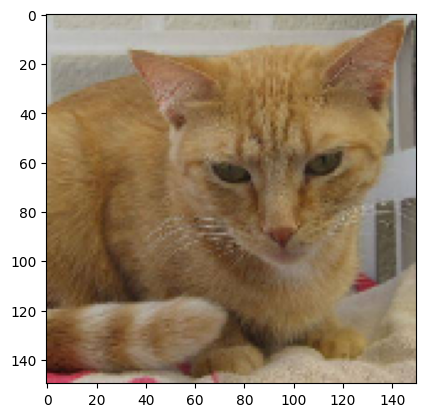

In [9]:
from tensorflow.keras.preprocessing.image import load_img,img_to_array
import random
x = load_img(x,target_size = (150,150))
x = img_to_array(x)
x /= 255.0
plt.imshow(x)

In [10]:
#investigating shape
x.shape

(150, 150, 3)

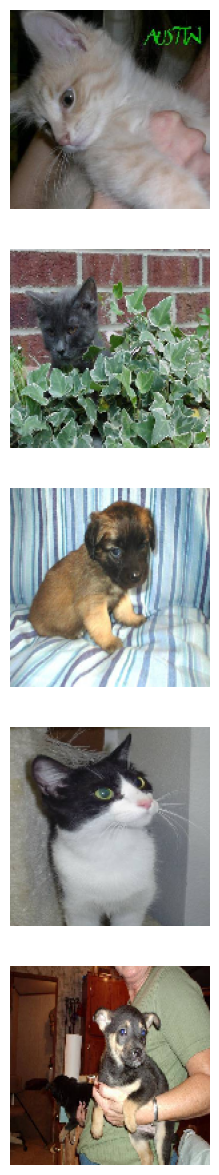

In [11]:
# 4
def plotImages(images_arr, probabilities = False):
    fig, axes = plt.subplots(len(images_arr), 1, figsize=(5,len(images_arr) * 3))
    if probabilities is False:
      for img, ax in zip( images_arr, axes):
          ax.imshow(img)
          ax.axis('off')
    else:
      for img, probability, ax in zip( images_arr, probabilities, axes):
          ax.imshow(img)
          ax.axis('off')
          if probability > 0.5:
              ax.set_title("%.2f" % (probability*100) + "% dog")
          else:
              ax.set_title("%.2f" % ((1-probability)*100) + "% cat")
    plt.show()

sample_training_images, _ = next(train_data_gen)
plotImages(sample_training_images[:5])


In [12]:
# 5
train_image_generator = ImageDataGenerator( rescale = 1./255,
rotation_range=15, # images will be randomly rotated by a degree of 15
width_shift_range=0.2,# Images will be randomly shifted horizontally by up to 20% of their total width.
height_shift_range=0.1,#img randomly shifted vertically
shear_range=0.1,# Images will be randomly sheared (tilted along an axis) by up to 20 degrees.
zoom_range=0.2, #Images will be randomly zoomed in by up to 20%
horizontal_flip=True, # randomly flipped
fill_mode='nearest')





Found 2000 images belonging to 2 classes.


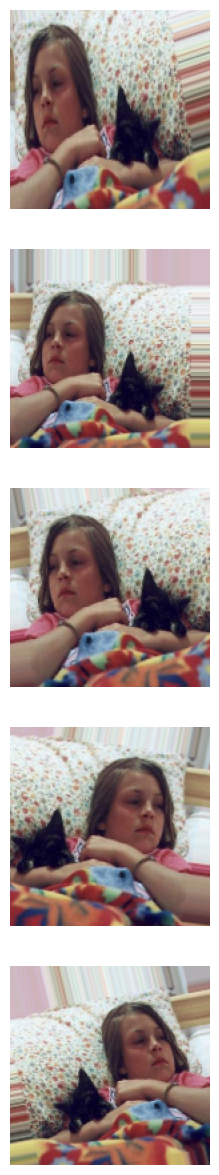

In [13]:
#applying data augmentation
train_data_gen = train_image_generator.flow_from_directory(batch_size=batch_size,
                                                     directory=train_dir,
                                                     target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                     class_mode='binary')

augmented_images = [train_data_gen[0][0][0] for i in range(5)]

plotImages(augmented_images)


# Model Architecture 4
Adding a dropout layer on top of architecture 2

In [15]:


# 7
#building model architecture
model = Sequential()
model.add(Input(shape = (IMG_HEIGHT,IMG_WIDTH,3))) #input shape

#first convolution layer
model.add(Conv2D((32),(5,5),activation = 'relu'))
model.add(MaxPooling2D((2,2))) #enhances feautures,reduces dimensionality

#second convolution layer
model.add(Conv2D((64),(3,3),activation = 'relu'))
model.add(MaxPooling2D((2,2))) #enhances feautures,reduces dimensionality

#third convolution

model.add(Conv2D((64),(3,3),activation = 'relu'))

#Flatten Layer
model.add(Flatten())

#Predition Dense Layer

model.add(Dense(128, activation= 'relu'))
model.add(Dense(64,activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid')) # 1 neuron as its binary



#model compiling

from tensorflow.keras.optimizers import SGD

# 1. Instantiate the optimizer with momentum
# 0.9 is a common starting value
opt = SGD(learning_rate=0.01, momentum=0.9)

model.compile(optimizer = opt,
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])






model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 146, 146, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 33, 33, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 69696)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     8,921,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,987,393 (34.28 MB)

 Trainable params: 8,987,393 (34.28 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
#training model
history = model.fit(train_data_gen,
                    steps_per_epoch= int(np.ceil(total_train / batch_size)), #should correspond directly to the total images divided by batch size
                    epochs = 20,
                    validation_data=val_data_gen,
                    validation_steps=int(np.ceil(total_val / batch_size)))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 114s 7s/step - accuracy: 0.4865 - loss: 0.6951 - val_accuracy: 0.5190 - val_loss: 0.6913
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 137s 7s/step - accuracy: 0.5155 - loss: 0.6916 - val_accuracy: 0.5150 - val_loss: 0.6879
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 142s 7s/step - accuracy: 0.5265 - loss: 0.6897 - val_accuracy: 0.5540 - val_loss: 0.6820
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 117s 7s/step - accuracy: 0.5375 - loss: 0.6877 - val_accuracy: 0.5880 - val_loss: 0.6802
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 108s 7s/step - accuracy: 0.5755 - loss: 0.6799 - val_accuracy: 0.5970 - val_loss: 0.6692
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 142s 7s/step - accuracy: 0.5655 - loss: 0.6786 - val_accuracy: 0.6190 - val_loss: 0.6678
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 109s 7s/step - accuracy: 0.5710 - loss: 0.6760 - val_accuracy: 0.5560 - val_loss: 0.6726
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 143s 7s/step - accuracy: 0.5715 - loss: 0.6745 - val_accuracy: 0.5350 - v

In [17]:
probabilities = model.predict(test_data_gen, steps = int(np.ceil(total_test / batch_size)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step


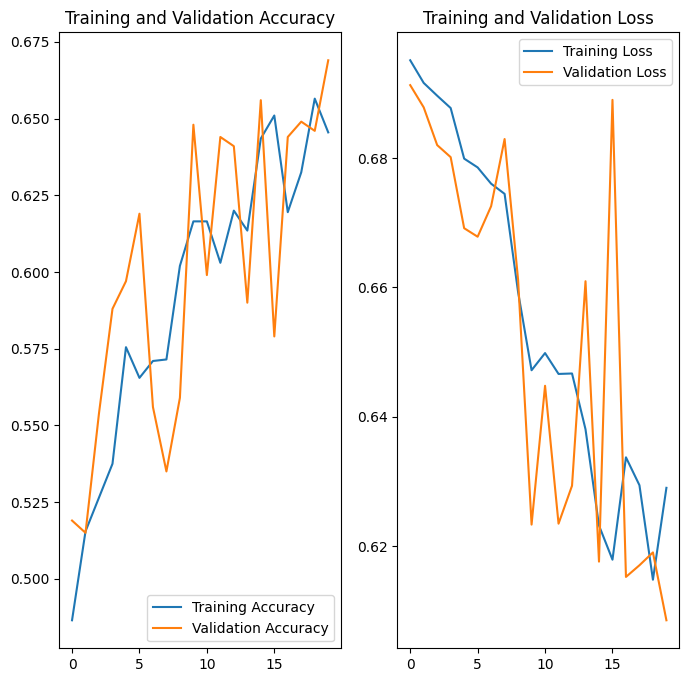

In [19]:
# 9
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(20)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [20]:
# 11
answers =  [1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
            1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
            1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
            1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
            0, 0, 0, 0, 0, 0]

correct = 0

for probability, answer in zip(probabilities, answers):
  if round(probability[0]) == answer:
    correct +=1

percentage_identified = (correct / len(answers)) * 100

passed_challenge = percentage_identified >= 63

print(f"Your model correctly identified {round(percentage_identified, 2)}% of the images of cats and dogs.")

if passed_challenge:
  print("You passed the challenge!")
else:
  print("You haven't passed yet. Your model should identify at least 63% of the images. Keep trying. You will get it!")

Your model correctly identified 60.0% of the images of cats and dogs.
You haven't passed yet. Your model should identify at least 63% of the images. Keep trying. You will get it!
